In [ ]:
!pip install ultralytics opencv-python matplotlib tqdm lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/PCB_defect_detection/PCB_DATASET"
IMG_DIR = BASE_PATH + "/images"
XML_DIR = BASE_PATH + "/Annotations"

In [ ]:
!ls $IMG_DIR | head
!ls $XML_DIR | head

Missing_hole
Mouse_bite
Open_circuit
Short
Spur
Spurious_copper
Missing_hole
Mouse_bite
Open_circuit
Short
Spur
Spurious_copper


In [ ]:
import os

# Get filenames (without extension)
image_files = set([os.path.splitext(f)[0] for f in os.listdir(IMG_DIR) if f.endswith(('.jpg', '.png'))])
xml_files = set([os.path.splitext(f)[0] for f in os.listdir(XML_DIR) if f.endswith('.xml')])

# Check mismatches
missing_xml = image_files - xml_files
missing_images = xml_files - image_files

print("Images without XML:", len(missing_xml))
print("XML without images:", len(missing_images))

if len(missing_xml) > 0:
    print("Example missing XML:", list(missing_xml)[:5])

if len(missing_images) > 0:
    print("Example missing images:", list(missing_images)[:5])

Images without XML: 0
XML without images: 0


In [ ]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Get first XML file from nested folders
sample_xml = None

for root_dir, _, files in os.walk(XML_DIR):
    for file in files:
        if file.endswith(".xml"):
            sample_xml = os.path.join(root_dir, file)
            break
    if sample_xml:
        break



In [ ]:
tree = ET.parse(sample_xml)
root = tree.getroot()

filename = root.find("filename").text
class_folder = root.find("folder").text

img_path = os.path.join(IMG_DIR, class_folder, filename)

# Fix path if needed (Windows)
if not os.path.exists(img_path):
    filename = root.find("filename").text
    img_path = os.path.join(IMG_DIR, filename)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



(np.float64(-0.5), np.float64(2528.5), np.float64(2529.5), np.float64(-0.5))

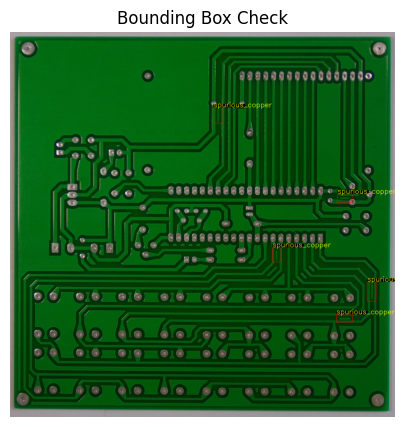

In [ ]:
# Draw bounding boxes
for obj in root.findall("object"):
    name = obj.find("name").text
    bbox = obj.find("bndbox")

    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    # Clamp properly
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(img.shape[1], xmax)
    ymax = min(img.shape[0], ymax)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    # Background box for text
    text_y = max(20, ymin)
    (text_w, text_h), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)

    cv2.rectangle(img,
                (xmin, text_y - text_h - 5),
                (xmin + text_w, text_y),
                (0, 0, 0),  # black background
                -1)

    cv2.putText(img,
                name,
                (xmin, text_y - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                (255, 255, 0),
                2)

plt.figure(figsize=(10,5))
plt.imshow(img)
plt.title("Bounding Box Check")
plt.axis("off")

In [ ]:
from tqdm import tqdm

In [ ]:
classes = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"
]

In [ ]:
import os
import xml.etree.ElementTree as ET
from tqdm import tqdm

LABEL_DIR = BASE_PATH + "/labels"
os.makedirs(LABEL_DIR, exist_ok=True)

def convert_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    folder = root.find("folder").text

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    label_path = os.path.join(LABEL_DIR, filename.replace(".jpg", ".txt"))

    with open(label_path, "w") as f:
        for obj in root.findall("object"):
            cls = obj.find("name").text.lower()

            if cls not in classes:
                continue

            cls_id = classes.index(cls)

            bbox = obj.find("bndbox")

            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(w, xmax)
            ymax = min(h, ymax)

            if xmax <= xmin or ymax <= ymin:
                continue

            x_center = (xmin + xmax) / 2 / w
            y_center = (ymin + ymax) / 2 / h
            bw = (xmax - xmin) / w
            bh = (ymax - ymin) / h

            f.write(f"{cls_id} {x_center} {y_center} {bw} {bh}\n")

# Run conversion
xml_files = []
for root_dir, _, files in os.walk(XML_DIR):
    for file in files:
        if file.endswith(".xml"):
            xml_files.append(os.path.join(root_dir, file))

for xml_file in tqdm(xml_files):
    convert_xml(xml_file)

print("✅ Conversion done")

100%|██████████| 693/693 [08:15<00:00,  1.40it/s]

✅ Conversion done


In [ ]:
print("Images:", len(xml_files))
print("Labels:", len(os.listdir(LABEL_DIR)))

Images: 693
Labels: 697


In [ ]:
for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:

    path = os.path.join(BASE_PATH, folder)

    if os.path.exists(path):
        shutil.rmtree(path)

print("✅ Old splits removed")

✅ Old splits removed


In [ ]:
# Create new folders
for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:

    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

print("✅ New folders created")

✅ New folders created


In [ ]:
IMG_DIR = BASE_PATH + "/images"
LABEL_DIR = BASE_PATH + "/labels"

all_images = []

for root_dir, _, files in os.walk(IMG_DIR):

    # skip split folders if present
    if any(x in root_dir for x in ["train", "val", "test"]):
        continue

    for file in files:
        if file.endswith(".jpg"):
            all_images.append(os.path.join(root_dir, file))

print("Total images:", len(all_images))

Total images: 693


In [ ]:
import random

random.seed(42)
random.shuffle(all_images)

n = len(all_images)

train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_files = all_images[:train_end]
val_files = all_images[train_end:val_end]
test_files = all_images[val_end:]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 485
Val: 138
Test: 70


In [ ]:
def copy_files(file_list, split):

    for img_path in file_list:
        name = os.path.basename(img_path)
        label = name.replace(".jpg", ".txt")

        # destination paths
        img_dest = os.path.join(BASE_PATH, "images", split, name)
        lbl_dest = os.path.join(BASE_PATH, "labels", split, label)

        shutil.copy(img_path, img_dest)

        label_path = os.path.join(LABEL_DIR, label)

        if os.path.exists(label_path):
            shutil.copy(label_path, lbl_dest)
        else:
            print(f"⚠️ Missing label: {label}")

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

print("✅ Split completed")

✅ Split completed


In [ ]:
def count_check(split):
    img_count = len(os.listdir(os.path.join(BASE_PATH, "images", split)))
    lbl_count = len(os.listdir(os.path.join(BASE_PATH, "labels", split)))
    print(f"{split}: images={img_count}, labels={lbl_count}")

count_check("train")
count_check("val")
count_check("test")

train: images=485, labels=485
val: images=138, labels=138
test: images=70, labels=70


In [ ]:
yaml_content = f"""
path: {BASE_PATH}

train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper
"""

with open("pcb.yaml", "w") as f:
    f.write(yaml_content)

print("✅ YAML updated")

✅ YAML updated


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="pcb.yaml",
    epochs=50,
    imgsz=800,
    batch=16,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,

    flipud=0.5,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    name="yolov8n_clean"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pcb.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_clean, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x784e494479e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

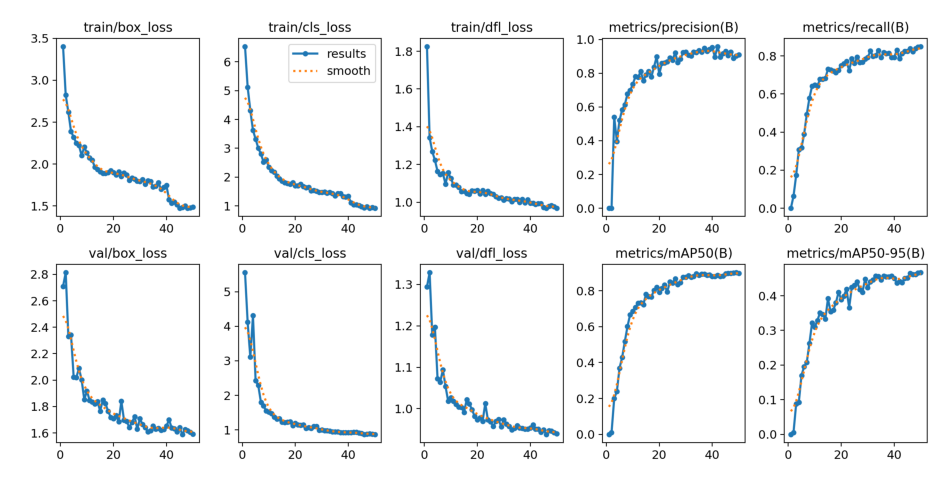

In [ ]:
from PIL import Image

img = Image.open("runs/detect/yolov8n_clean/results.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

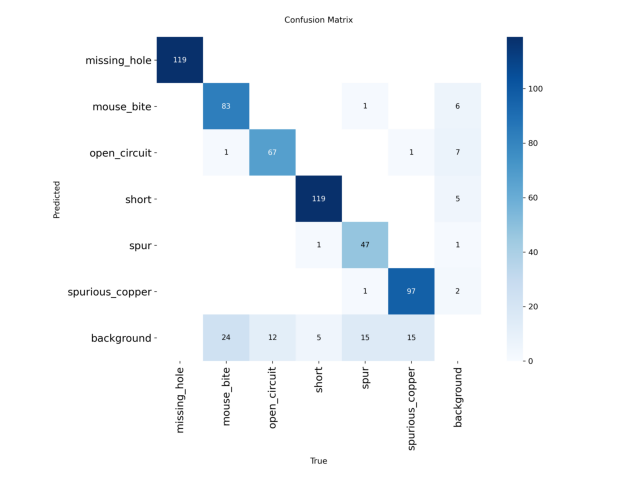

In [ ]:
img = Image.open("runs/detect/yolov8n_pcb/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

In [ ]:
model = YOLO("runs/detect/yolov8n_clean/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test",
    save=True,
    conf=0.25
)


image 1/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_03.jpg: 448x800 3 missing_holes, 46.6ms
image 2/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_12.jpg: 448x800 3 missing_holes, 6.9ms
image 3/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_16.jpg: 448x800 3 missing_holes, 6.9ms
image 4/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_07.jpg: 448x800 (no detections), 6.9ms
image 5/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_09.jpg: 448x800 (no detections), 6.9ms
image 6/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_10.jpg: 448x800 (no detections), 6.9ms
image 7/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_19.jpg: 448x800 (no detections), 6.9ms
image 8/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/i

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'missing_hole', 1: 'mouse_bite', 2: 'open_circuit', 3: 'short', 4: 'spur', 5: 'spurious_copper'}
 obb: None
 orig_img: array([[[139, 138, 147],
         [137, 136, 145],
         [134, 133, 142],
         ...,
         [155, 151, 157],
         [151, 147, 153],
         [154, 150, 156]],
 
        [[138, 137, 147],
         [138, 137, 147],
         [135, 134, 143],
         ...,
         [153, 149, 155],
         [150, 146, 152],
         [153, 149, 155]],
 
        [[139, 138, 148],
         [142, 141, 151],
         [142, 141, 151],
         ...,
         [152, 148, 154],
         [150, 146, 152],
         [152, 148, 154]],
 
        ...,
 
        [[138, 134, 140],
         [144, 140, 146],
         [141, 137, 143],
         ...,
         [153, 146, 151],
         [152, 146, 151],
         [155, 149, 154]],
 
        [[145, 139, 144

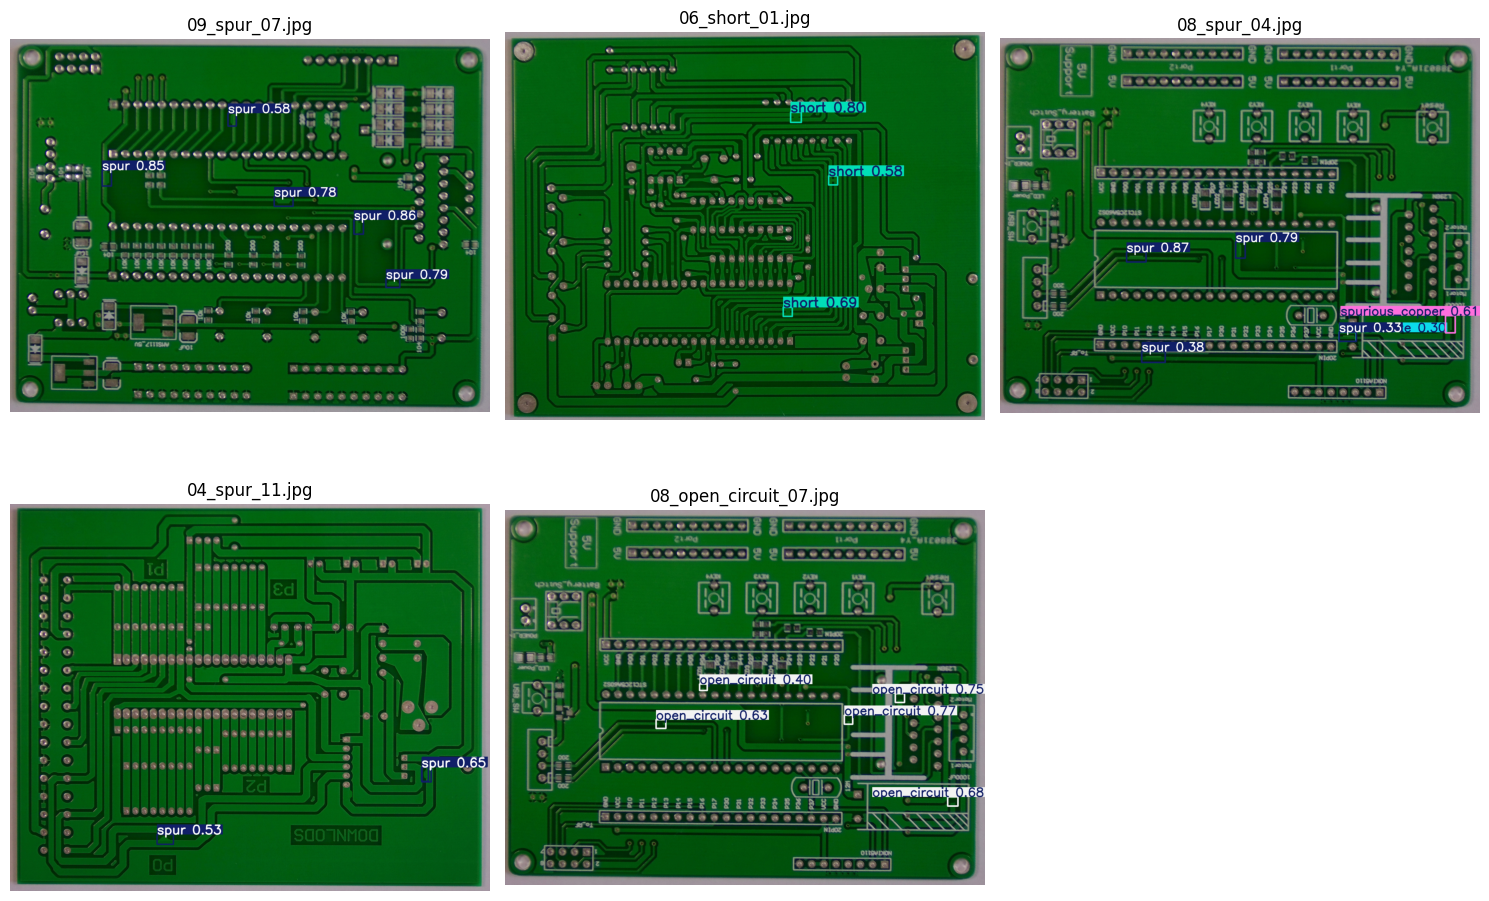

In [ ]:
PRED_DIR = "runs/detect/predict-2"

images = os.listdir(PRED_DIR)[:5]  # show first 5

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(PRED_DIR, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()

In [ ]:
import pandas as pd

df = pd.read_csv("runs/detect/yolov8n_pcb/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,2335.85,1.48923,0.94617,0.96226,0.92236,0.85316,0.89289,0.45934,1.61336,0.85054,0.94053,0.000109,0.000109,0.000109
46,47,2381.34,1.47658,0.90369,0.97192,0.97179,0.82824,0.89793,0.46665,1.59447,0.83043,0.93498,0.000089,0.000089,0.000089
47,48,2427.58,1.47652,0.91322,0.97146,0.96724,0.82891,0.89351,0.46951,1.58216,0.82717,0.93395,0.000069,0.000069,0.000069
48,49,2473.57,1.49462,0.90929,0.97561,0.95832,0.84657,0.89581,0.47175,1.57893,0.82919,0.93574,0.000050,0.000050,0.000050
49,50,2519.73,1.45976,0.88645,0.96758,0.94971,0.85232,0.89845,0.47488,1.57683,0.82225,0.93364,0.000030,0.000030,0.000030


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="pcb.yaml",
    epochs=70,
    imgsz=1024,   # 🔥 increase resolution
    batch=12,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,

    flipud=0.5,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    name="yolov8s_pcb2"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pcb.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_pcb2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x784d2366e2a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
import torch
import torch.nn.utils.prune as prune

# Load trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Access PyTorch model
pt_model = model.model

print("🔧 Applying pruning...")

# Apply pruning to Conv layers
for name, module in pt_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        prune.l1_unstructured(module, name="weight", amount=0.3)  # 30% pruning

# Remove pruning reparameterization
for name, module in pt_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        try:
            prune.remove(module, 'weight')
        except:
            pass

print("✅ Pruning completed")

In [ ]:
import shutil

shutil.copytree(
    "runs/detect/yolov8n_clean",
    "/content/drive/MyDrive/PCB_RESULTS/yolov8n_clean",
    dirs_exist_ok=True
)

shutil.copytree(
    "runs/detect/yolov8s_pcb2",
    "/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb",
    dirs_exist_ok=True
)

print("✅ Models saved to Drive")

✅ Models saved to Drive


In [ ]:
from ultralytics import YOLO

model_n = YOLO("/content/drive/MyDrive/PCB_RESULTS/yolov8n_clean/weights/best.pt")
model_s = YOLO("/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
yaml_content = f"""
path: {BASE_PATH}

train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper
"""

with open("pcb.yaml", "w") as f:
    f.write(yaml_content)

print("✅ YAML recreated")

✅ YAML recreated


In [ ]:
yaml_path = "/content/drive/MyDrive/PCB_RESULTS/pcb.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

In [ ]:
metrics_n = model_n.val(data="pcb.yaml", split="test")
metrics_s = model_s.val(data="pcb.yaml", split="test")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 1.9±0.6 MB/s, size: 1495.1 KB)
val: Scanning /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/labels/test... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 2.5s/it 2:54
val: New cache created: /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.5s/it 52.3s
                   all         70        288      0.888      0.832      0.888      0.442
          missing_hole          7         28      0.971          1      0.995      0.505
            mouse_bite         15         57      0.878      0.684      0.803      0.404
          open_circuit         11         43      0.862      0.767       0.83      0.361
                 short         11         51       0.96      0.933      0.953      0.504
       

In [ ]:
model_n.predict(source=f"{BASE_PATH}/images/test", save=True, name="pred_n")
model_s.predict(source=f"{BASE_PATH}/images/test", save=True, name="pred_s")


image 1/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_03.jpg: 448x800 3 missing_holes, 70.3ms
image 2/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_12.jpg: 448x800 3 missing_holes, 24.4ms
image 3/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_16.jpg: 448x800 3 missing_holes, 12.2ms
image 4/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_07.jpg: 448x800 (no detections), 43.0ms
image 5/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_09.jpg: 448x800 (no detections), 10.2ms
image 6/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_10.jpg: 448x800 (no detections), 11.4ms
image 7/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_19.jpg: 448x800 (no detections), 24.8ms
image 8/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DAT

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'missing_hole', 1: 'mouse_bite', 2: 'open_circuit', 3: 'short', 4: 'spur', 5: 'spurious_copper'}
 obb: None
 orig_img: array([[[139, 138, 147],
         [137, 136, 145],
         [134, 133, 142],
         ...,
         [155, 151, 157],
         [151, 147, 153],
         [154, 150, 156]],
 
        [[138, 137, 147],
         [138, 137, 147],
         [135, 134, 143],
         ...,
         [153, 149, 155],
         [150, 146, 152],
         [153, 149, 155]],
 
        [[139, 138, 148],
         [142, 141, 151],
         [142, 141, 151],
         ...,
         [152, 148, 154],
         [150, 146, 152],
         [152, 148, 154]],
 
        ...,
 
        [[138, 134, 140],
         [144, 140, 146],
         [141, 137, 143],
         ...,
         [153, 146, 151],
         [152, 146, 151],
         [155, 149, 154]],
 
        [[145, 139, 144

In [ ]:
print("YOLOv8n")
print("Precision:", metrics_n.box.p)
print("Recall:", metrics_n.box.r)
print("mAP50:", metrics_n.box.map50)
print("mAP50-95:", metrics_n.box.map)

print("\nYOLOv8s")
print("Precision:", metrics_s.box.p)
print("Recall:", metrics_s.box.r)
print("mAP50:", metrics_s.box.map50)
print("mAP50-95:", metrics_s.box.map)

YOLOv8n
Precision: [    0.97078     0.87837     0.86151     0.95966     0.97368       0.683]
Recall: [          1     0.68421     0.76744      0.9331     0.67692     0.93182]
mAP50: 0.8884541517585118
mAP50-95: 0.4417957093553413

YOLOv8s
Precision: [    0.98791      0.9803     0.97699     0.91155     0.98301     0.99711]
Recall: [          1     0.96491      0.9877     0.96078     0.89042     0.97727]
mAP50: 0.9702399713105554
mAP50-95: 0.531887661840578


In [ ]:
print(metrics_n)
print(metrics_s)

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aee72b034a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
model_s.predict(source=f"{BASE_PATH}/images/test", save=True, conf=0.25)


image 1/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_03.jpg: 544x1024 3 missing_holes, 20.3ms
image 2/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_12.jpg: 544x1024 3 missing_holes, 21.6ms
image 3/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_missing_hole_16.jpg: 544x1024 3 missing_holes, 20.7ms
image 4/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_07.jpg: 544x1024 2 mouse_bites, 20.0ms
image 5/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_09.jpg: 544x1024 2 mouse_bites, 19.5ms
image 6/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_10.jpg: 544x1024 2 mouse_bites, 21.2ms
image 7/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test/01_mouse_bite_19.jpg: 544x1024 (no detections), 32.3ms
image 8/70 /content/drive/MyDrive/PCB_defect_detection/PCB_DA

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'missing_hole', 1: 'mouse_bite', 2: 'open_circuit', 3: 'short', 4: 'spur', 5: 'spurious_copper'}
 obb: None
 orig_img: array([[[139, 138, 147],
         [137, 136, 145],
         [134, 133, 142],
         ...,
         [155, 151, 157],
         [151, 147, 153],
         [154, 150, 156]],
 
        [[138, 137, 147],
         [138, 137, 147],
         [135, 134, 143],
         ...,
         [153, 149, 155],
         [150, 146, 152],
         [153, 149, 155]],
 
        [[139, 138, 148],
         [142, 141, 151],
         [142, 141, 151],
         ...,
         [152, 148, 154],
         [150, 146, 152],
         [152, 148, 154]],
 
        ...,
 
        [[138, 134, 140],
         [144, 140, 146],
         [141, 137, 143],
         ...,
         [153, 146, 151],
         [152, 146, 151],
         [155, 149, 154]],
 
        [[145, 139, 144

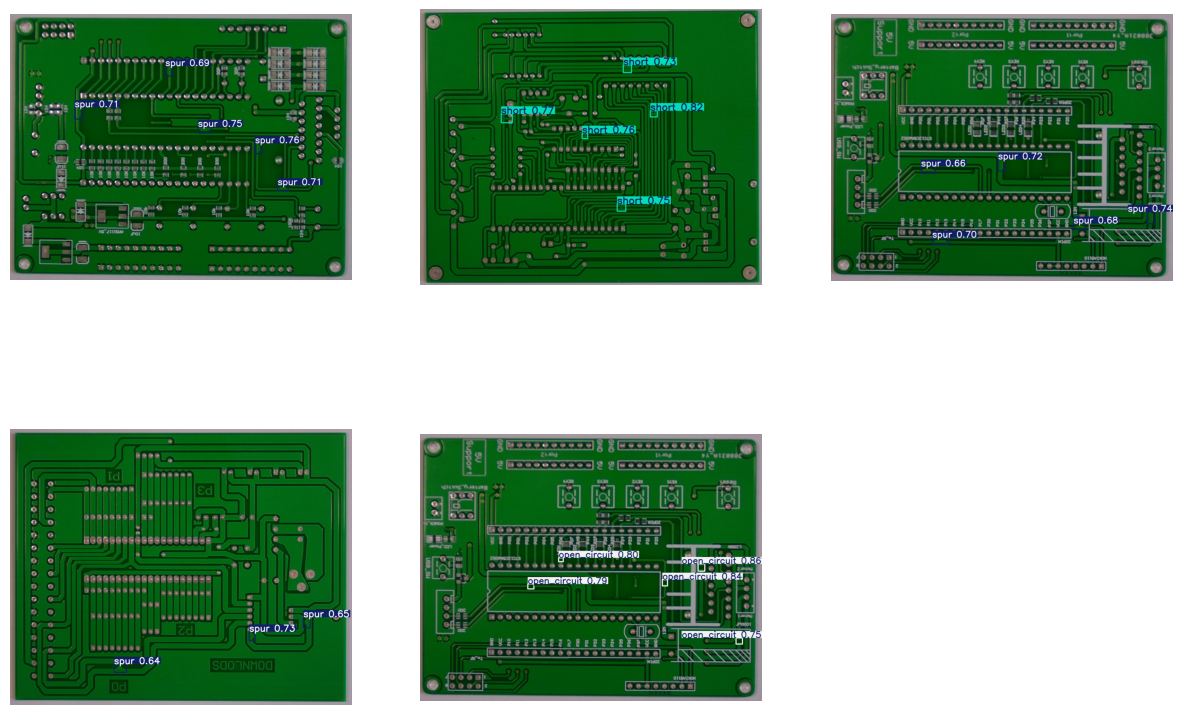

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

PRED_DIR = "/content/runs/detect/pred_s"

images = os.listdir(PRED_DIR)[:5]

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(PRED_DIR, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    pip3 install ultralytics openvino opencv-python

plt.show()

In [ ]:
model_s.export(format="openvino")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 10, 21504) (21.6 MB)

OpenVINO: starting export with openvino 2026.1.0-21367-63e31528c62-releases/2026/1...
OpenVINO: export success ✅ 8.2s, saved as '/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_openvino_model/' (42.9 MB)

Export complete (10.7s)
Results saved to /content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_openvino_model/ imgsz=1024 
Validate:        yolo val task=detect model=/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_openvino_model/ imgsz=1024 data=pcb.yaml  
Visualize:       https://netron.app


'/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_openvino_model/'

In [ ]:
import shutil

shutil.copytree(
    "/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_openvino_model",
    "/content/drive/MyDrive/PCB_RESULTS/openvino_model",
    dirs_exist_ok=True
)

print("✅ OpenVINO model saved")

✅ OpenVINO model saved


In [ ]:
model_s.export(format="tflite")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 10, 21504) (21.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 207ms
Prepared 4 packages in 1.37s
Installed 4 packages in 311ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 2.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset

'/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_saved_model/best_float32.tflite'